In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:

#load the datset
df = pd.read_csv(r'C:\Users\inter\Desktop\Mansi\Machine Learning\heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:

df.shape

(1025, 14)

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:

df['target'].unique()

array([0, 1])

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


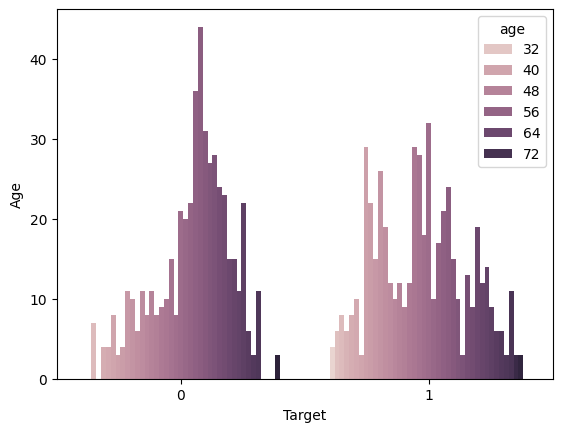

In [11]:
sns.countplot(data=df,x='target',hue='age');
plt.xlabel('Target')
plt.ylabel('Age')
plt.show()

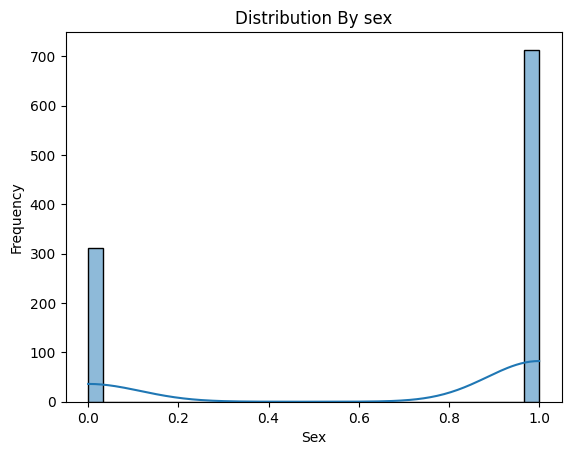

In [12]:
sns.histplot(df['sex'], bins=30, kde=True)
plt.title('Distribution By sex')
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.show()

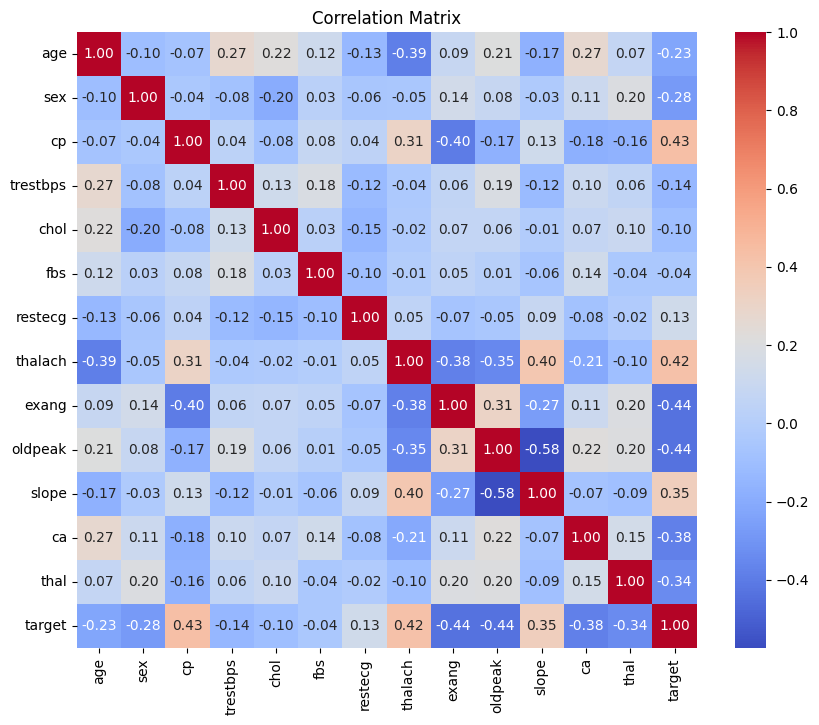

In [13]:
numeric = df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

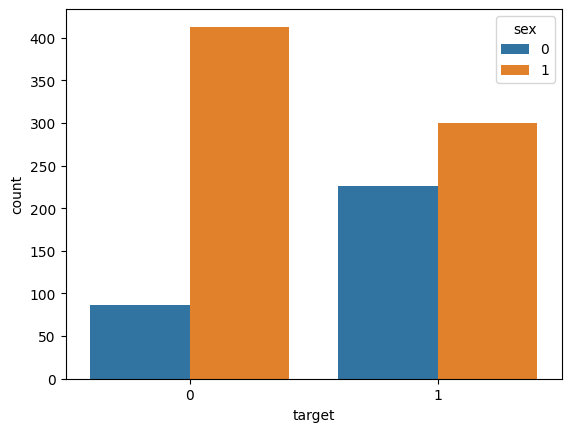

In [14]:
sns.countplot(data=df,x='target',hue='sex');

C:\Users\inter\AppData\Local\Temp\ipykernel_2524\930080491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target', y='age', data=df,palette='muted')


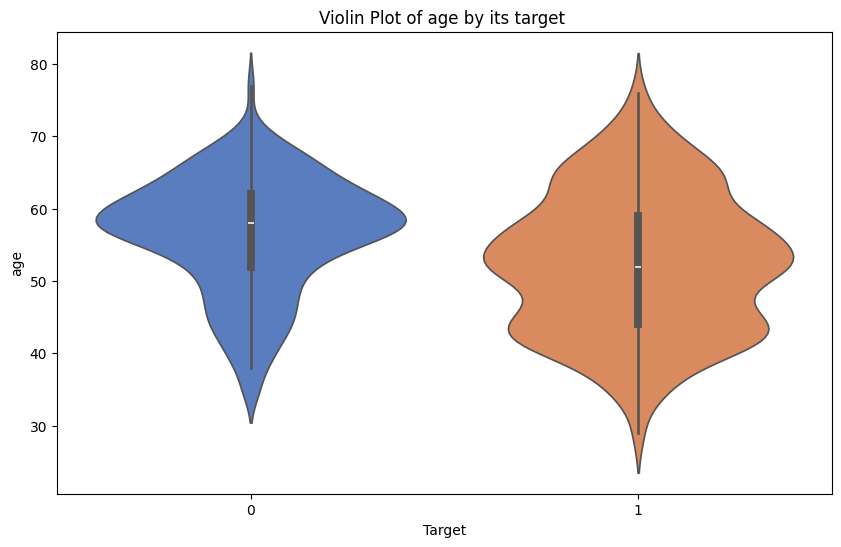

In [15]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='target', y='age', data=df,palette='muted')
plt.title('Violin Plot of age by its target ')
plt.xlabel('Target')
plt.ylabel('age')
plt.show()

C:\Users\inter\AppData\Local\Temp\ipykernel_2524\1470348724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(x='target', y='chol', data=df, palette='cool')


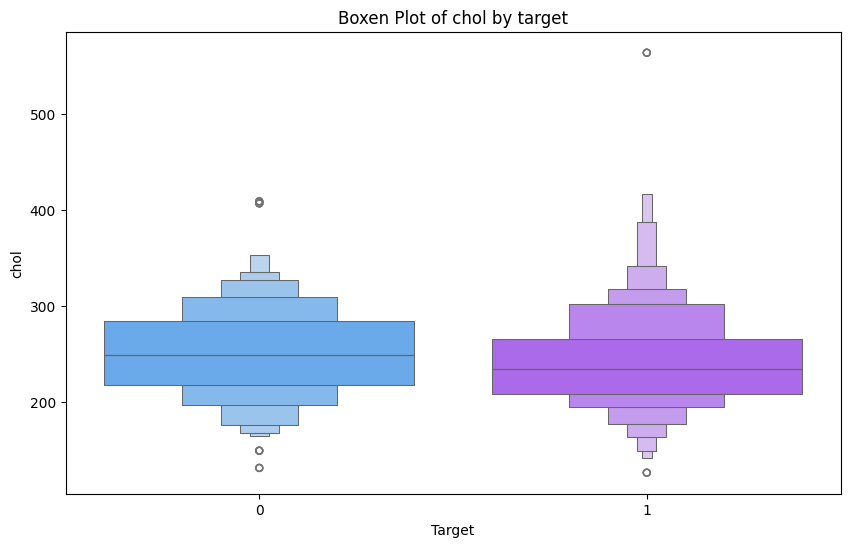

In [16]:
plt.figure(figsize=(10, 6))
sns.boxenplot(x='target', y='chol', data=df, palette='cool')
plt.title('Boxen Plot of chol by target')
plt.xlabel('Target')
plt.ylabel('chol')
plt.show()

In [17]:
import pickle 
# Check for non-numeric entries in the dataset
df.replace('?', np.nan, inplace=True)  
df.dropna(inplace=True)
df=df.astype(float)

X=df.drop('target',axis=1)
y=df['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

with open('scaler.pkl','wb')as scaler_file:
    pickle.dump(scaler,scaler_file)


with open('scaler.pkl','rb')as scaler_file:
    scaler=pickle.load(scaler_file)

In [18]:
log_reg=LogisticRegression()
log_reg.fit(X_train,y_train)
y_pred_log_reg=log_reg.predict(X_test)
accuracy_log_reg=accuracy_score(y_test,y_pred_log_reg)
conf_matrix_log_reg=confusion_matrix(y_test,y_pred_log_reg)
class_report_log_reg=classification_report(y_test,y_pred_log_reg)
print(f"Logistic Regression Accuracy:{accuracy_log_reg:.2f}")
print('confusion_matrix:')
print(conf_matrix_log_reg)
print('classification_report:')
print(class_report_log_reg)

Logistic Regression Accuracy:0.80
confusion_matrix:
[[73 29]
 [13 90]]
classification_report:
              precision    recall  f1-score   support

         0.0       0.85      0.72      0.78       102
         1.0       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [19]:
tree_clf=DecisionTreeClassifier()
tree_clf.fit(X_train,y_train)
y_pred_tree=tree_clf.predict(X_test)
accuracy_tree=accuracy_score(y_test,y_pred_tree)
conf_matrix_tree=confusion_matrix(y_test,y_pred_tree)
class_report_tree=classification_report(y_test,y_pred_tree)
print(f'Decision Tree Accuracy:{accuracy_tree:.2f}')
print('Confusion matrix:')
print(conf_matrix_tree)
print('classification_report')
print(class_report_tree)

Decision Tree Accuracy:0.99
Confusion matrix:
[[102   0]
 [  3 100]]
classification_report
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99       102
         1.0       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [20]:
import pickle
knn_clf=KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train,y_train)
y_pred_knn=knn_clf.predict(X_test)
accuracy_knn=accuracy_score(y_test,y_pred_knn)
conf_matrix_knn=confusion_matrix(y_test,y_pred_knn)
class_report_knn=classification_report(y_test,y_pred_knn)
print(f'k-NN Accuracy:{accuracy_knn:.2f}')
print('Confusion matrix:')
print(conf_matrix_knn)
print('classification_report')
print(class_report_knn)

file_name='Heart_disease_model.pickle'
pickle.dump(knn_clf,open(file_name,'wb'))
loaded_model=pickle.load(open(file_name,'rb'))

k-NN Accuracy:0.83
Confusion matrix:
[[79 23]
 [11 92]]
classification_report
              precision    recall  f1-score   support

         0.0       0.88      0.77      0.82       102
         1.0       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



In [21]:
from sklearn import svm

clf = svm.SVC(decision_function_shape='ovo')
clf.fit(X_test,y_test)
y_pred_clf=clf.predict(X_test)
accuracy_clf=accuracy_score(y_test,y_pred_clf)
conf_matrix_clf=confusion_matrix(y_test,y_pred_clf) 
class_report_clf=classification_report(y_test,y_pred_clf)
print(f'SVM:{accuracy_clf:.2f}')
print('Confusion matrix:')
print(conf_matrix_clf)
print('classification_report')
print(class_report_clf)

SVM:0.92
Confusion matrix:
[[98  4]
 [12 91]]
classification_report
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92       102
         1.0       0.96      0.88      0.92       103

    accuracy                           0.92       205
   macro avg       0.92      0.92      0.92       205
weighted avg       0.92      0.92      0.92       205



In [22]:
from sklearn.linear_model import SGDClassifier
classify=SGDClassifier(loss='hinge',penalty='l2',max_iter=5)
classify.fit(X_test,y_test)
y_pred_classify=classify.predict(X_test)
accuracy_classify=accuracy_score(y_test,y_pred_classify)
conf_matrix_classify=confusion_matrix(y_test,y_pred_classify) 
class_report_classify=classification_report(y_test,y_pred_classify)
print(f'SGD:{accuracy_classify:.2f}')
print('Confusion matrix:')
print(conf_matrix_classify)
print('classification_report')
print(class_report_classify)

SGD:0.78
Confusion matrix:
[[70 32]
 [14 89]]
classification_report
              precision    recall  f1-score   support

         0.0       0.83      0.69      0.75       102
         1.0       0.74      0.86      0.79       103

    accuracy                           0.78       205
   macro avg       0.78      0.78      0.77       205
weighted avg       0.78      0.78      0.77       205



c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


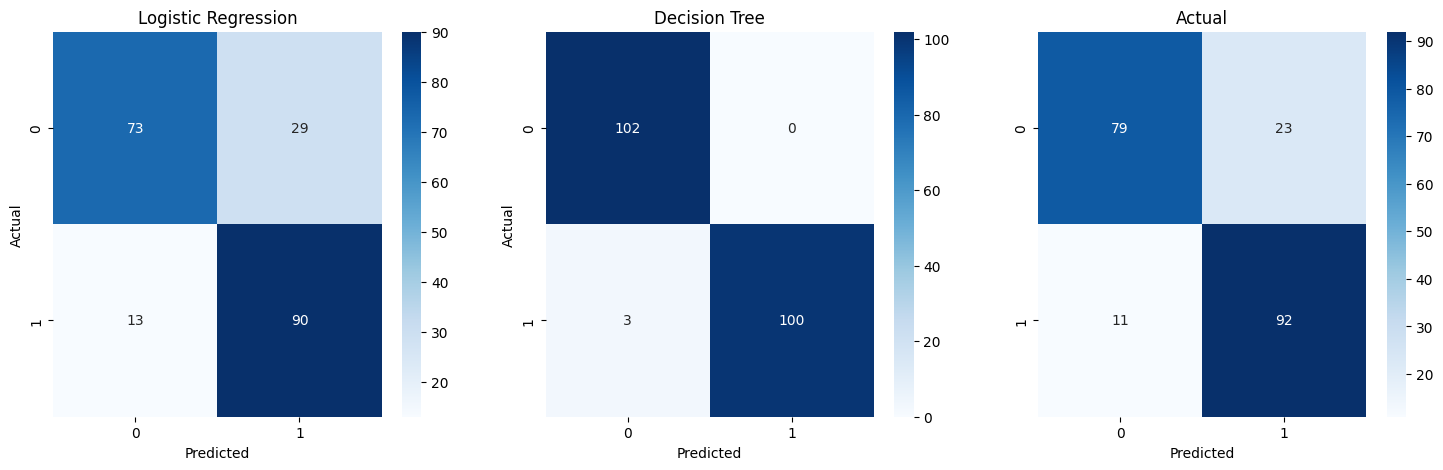

In [23]:
#visualizing 
fig,axes=plt.subplots(1,3,figsize=(18,5))
#logistic regression
sns.heatmap(conf_matrix_log_reg,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

#Decision Tree
sns.heatmap(conf_matrix_tree,annot=True,fmt='d',cmap='Blues',ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

#knn
sns.heatmap(conf_matrix_knn,annot=True,fmt='d',cmap='Blues',ax=axes[2])
axes[2].set_title('k-NN')
axes[2].set_xlabel('Predicted')
axes[2].set_title('Actual')
plt.show()

In [30]:
import pickle
import numpy as np

def infer_heart_disease(model_path, scaler_path, input_features):
    """
    Perform inferencing on the heart disease dataset.


Parameters:
    - model_path (str): Path to the saved model pickle file.
    - scaler_path (str): Path to the saved scaler pickle file.
    - input_features (list): List of input features in the order:
      [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]

    Returns:
    - str: "Disease Detected" if target is 1, otherwise "No Disease".
    """
    try:
        # Load the trained model and scaler
        with open(r'C:\Users\inter\Desktop\Mansi\Machine Learning\Heart_disease_model.pickle', 'rb') as model_file:
            model = pickle.load(model_file)

        with open(r'C:\Users\inter\Desktop\Mansi\Machine Learning\scaler.pkl', 'rb') as scaler_file:
            scaler = pickle.load(scaler_file)

        # Ensure the input features are in the correct format
        input_array = np.array([input_features]).reshape(1, -1)

        # Scale the input features
        scaled_input = scaler.transform(input_array)

        # Predict outcome
        prediction = model.predict(scaled_input)

        # Return result
        return "Disease Detected" if prediction[0] == 1 else "No Disease"

    except Exception as e:
        return f"An error occurred: {e}"

In [31]:
# Example input: Replace with actual feature values
input_features = [45, 1, 3, 120, 233, 0, 1, 150, 0, 2.3, 0, 0, 1]

# Paths to your saved model and scaler
model_path = r'C:\\Users\\inter\\Desktop\\Mansi\\Machine Learning\\Heart_disease_model.pickle'
scaler_path = r'C:\\Users\\inter\\Desktop\\Mansi\\Machine Learning\\scaler.pkl'

# Perform inference
result = infer_heart_disease(model_path, scaler_path, input_features)
print(result)

No Disease


c:\Users\inter\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
